# Laboratorio 5: Mineria de Textos y Analisis de Sentimiento

**CC3084 - Data Science, Universidad del Valle de Guatemala**

Integrantes:
- Javier Eduardo España (23361)
- Angel Esteban Esquit (23221)
- Roberto Jose Barreda (23354)

## 1. Carga de datos (ejercicios 1 y 2)

In [1]:
import os
import re
import string

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import opinion_lexicon, stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from scipy.sparse import csr_matrix, hstack
from scipy.stats import mannwhitneyu
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f'Train: {train_df.shape}   Test: {test_df.shape}')
train_df.head()

Train: (7613, 5)   Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Analisis exploratorio (ejercicio 5)

In [2]:
print(train_df.info())
print('\nValores nulos:')
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

Valores nulos:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


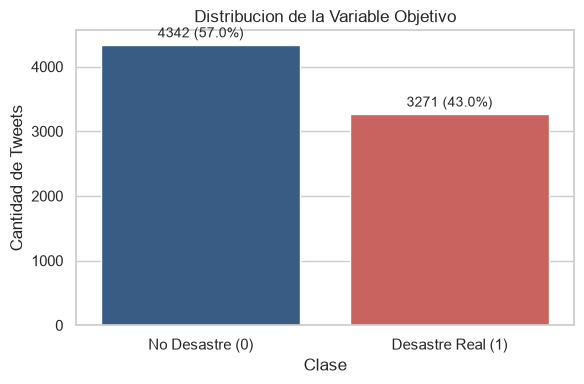

In [3]:
plt.figure(figsize=(6, 4))
counts = train_df['target'].value_counts()
ax = sns.barplot(x=counts.index, y=counts.values, palette=['#2b5c8f', '#d9534f'], hue=counts.index, legend=False)
plt.title('Distribucion de la Variable Objetivo')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Tweets')
plt.xticks([0, 1], ['No Desastre (0)', 'Desastre Real (1)'])
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{int(h)} ({h / len(train_df) * 100:.1f}%)',
                (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom',
                fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

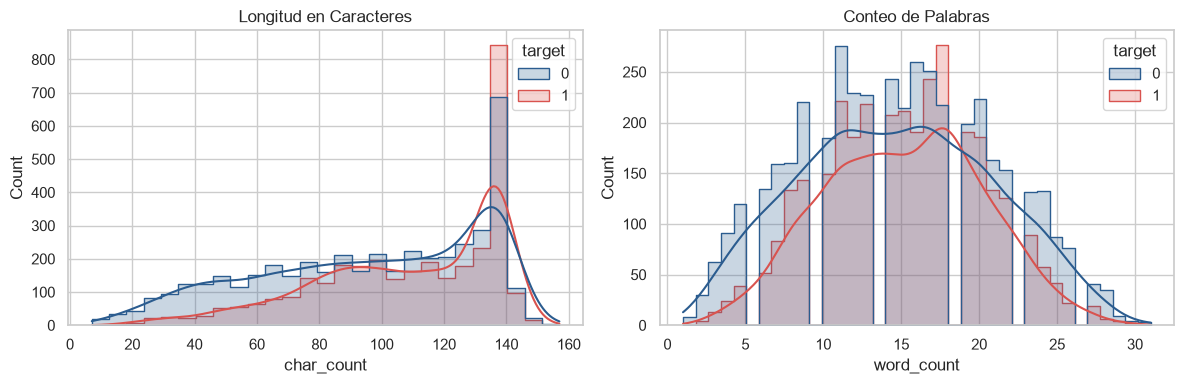

In [4]:
train_df['char_count'] = train_df['text'].astype(str).apply(len)
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train_df, x='char_count', hue='target', kde=True, ax=axes[0],
             palette=['#2b5c8f', '#d9534f'], element='step')
axes[0].set_title('Longitud en Caracteres')
sns.histplot(data=train_df, x='word_count', hue='target', kde=True, ax=axes[1],
             palette=['#2b5c8f', '#d9534f'], element='step')
axes[1].set_title('Conteo de Palabras')
plt.tight_layout()
plt.show()

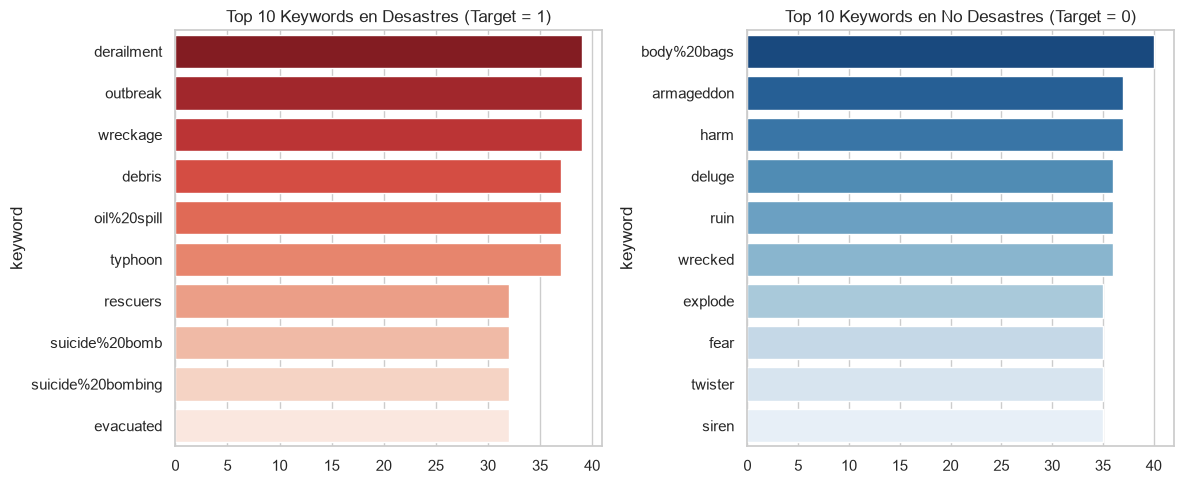

In [5]:
top_disaster = train_df[train_df['target'] == 1]['keyword'].value_counts().head(10)
top_nondisaster = train_df[train_df['target'] == 0]['keyword'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=top_disaster.values, y=top_disaster.index, ax=axes[0],
            palette='Reds_r', hue=top_disaster.index, legend=False)
axes[0].set_title('Top 10 Keywords en Desastres (Target = 1)')
sns.barplot(x=top_nondisaster.values, y=top_nondisaster.index, ax=axes[1],
            palette='Blues_r', hue=top_nondisaster.index, legend=False)
axes[1].set_title('Top 10 Keywords en No Desastres (Target = 0)')
plt.tight_layout()
plt.show()

## 3. Limpieza y preprocesamiento (ejercicio 3)

In [6]:
for res in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(res, quiet=True)

stop_words = set(stopwords.words('english')).union(
    {'u', 'im', 'amp', 'via', 'get', 'would', 'one', 'like', 'dont', 'cant', 'also'})
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'&[a-z]+;', ' ', text)                       # entidades HTML
    text = re.sub(r'@\w+', '', text)                            # menciones
    text = re.sub(r'#(\w+)', r'\1', text)                       # hashtags
    text = re.sub(r'\b911\b', ' emergency911 ', text)           # se preserva el 911
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[' + re.escape(string.punctuation) + ']', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)


train_df['cleaned_text'] = train_df['text'].apply(clean_text)
train_df[['text', 'cleaned_text']].head(5)

,text,cleaned_text
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...


## 4. Frecuencias y n-gramas (ejercicio 4)

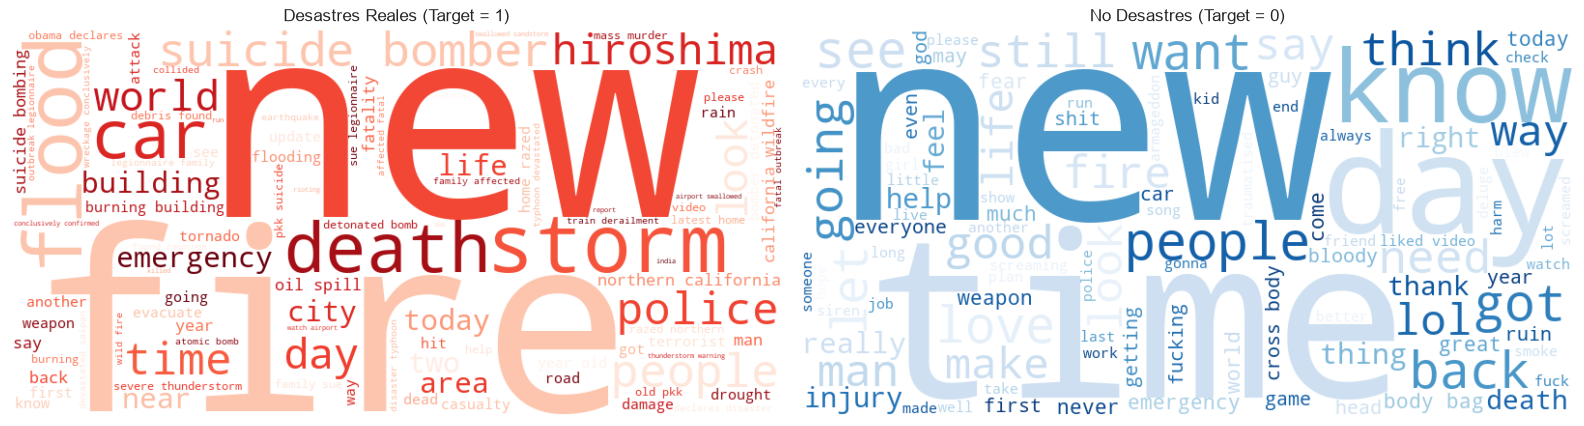

In [7]:
disaster_text = ' '.join(train_df[train_df['target'] == 1]['cleaned_text'])
nondisaster_text = ' '.join(train_df[train_df['target'] == 0]['cleaned_text'])

wc_disaster = WordCloud(width=800, height=400, background_color='white',
                        colormap='Reds', max_words=100, random_state=42).generate(disaster_text)
wc_nondisaster = WordCloud(width=800, height=400, background_color='white',
                           colormap='Blues', max_words=100, random_state=42).generate(nondisaster_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].set_title('Desastres Reales (Target = 1)')
axes[0].axis('off')
axes[1].imshow(wc_nondisaster, interpolation='bilinear')
axes[1].set_title('No Desastres (Target = 0)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

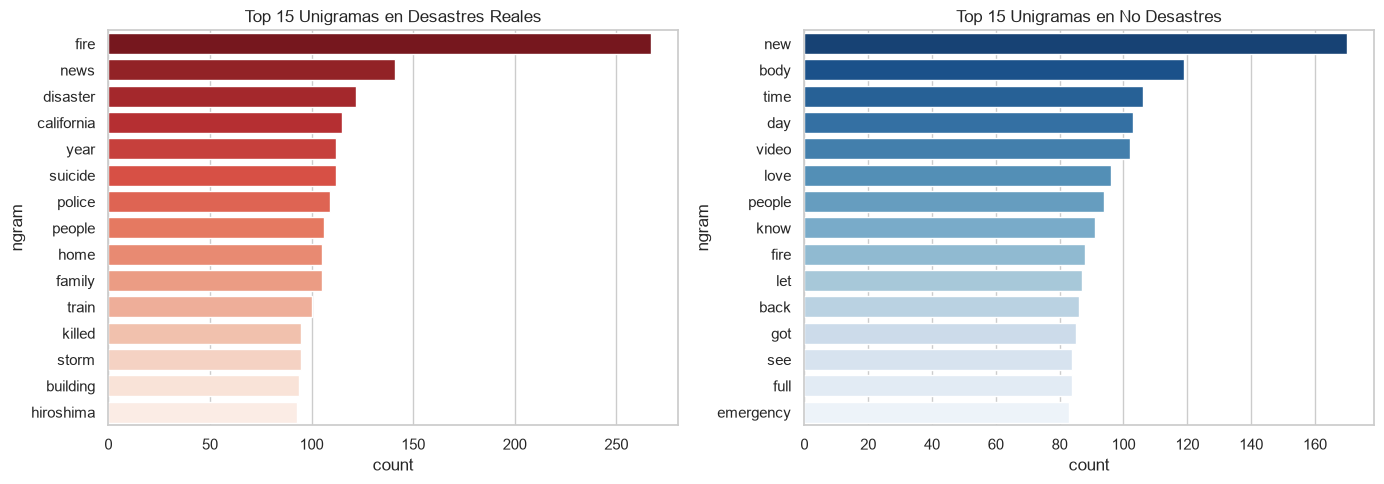

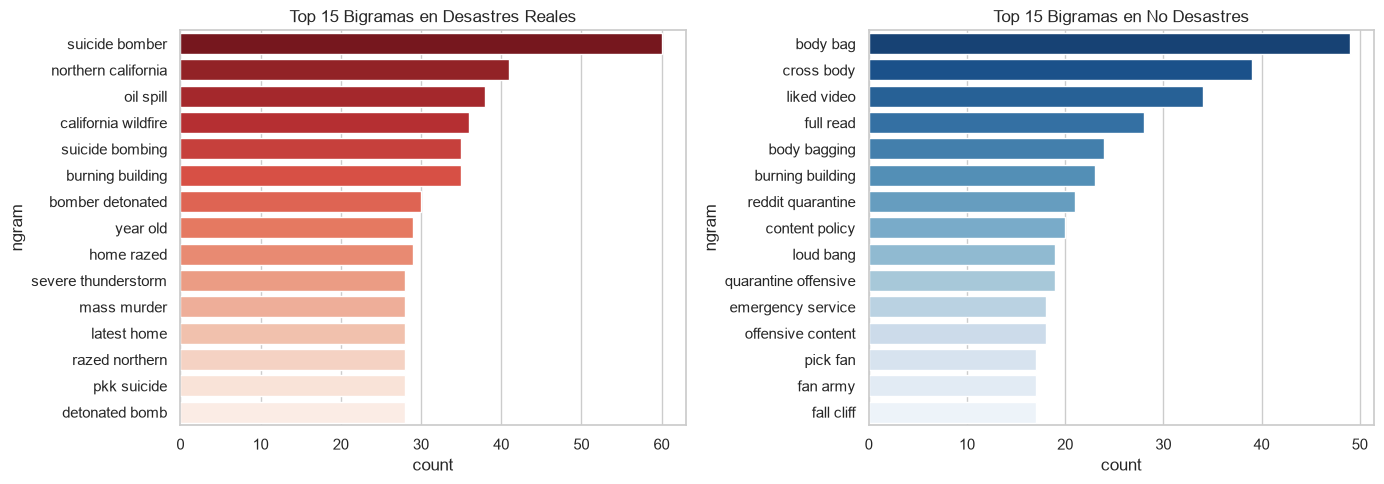

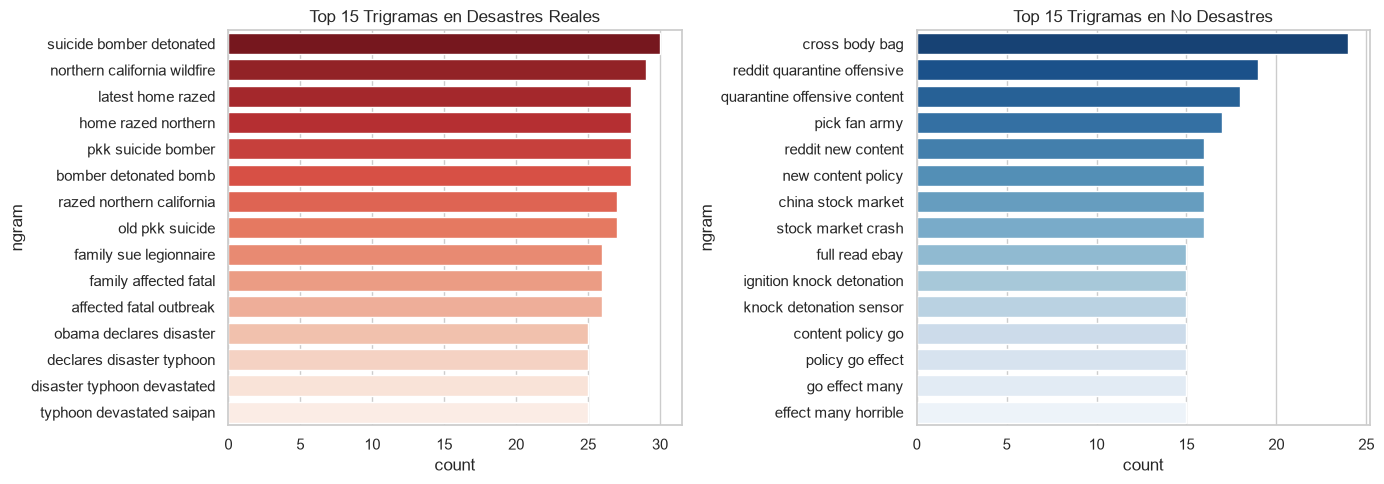

In [8]:
def get_top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)
    freq = sorted(((w, sums[0, i]) for w, i in vec.vocabulary_.items()),
                  key=lambda x: x[1], reverse=True)
    df = pd.DataFrame(freq[:top_k], columns=['ngram', 'count'])
    df['probability'] = df['count'] / int(sums.sum())
    return df


disaster_corpus = train_df[train_df['target'] == 1]['cleaned_text']
nondisaster_corpus = train_df[train_df['target'] == 0]['cleaned_text']

for n, nombre in [(1, 'Unigramas'), (2, 'Bigramas'), (3, 'Trigramas')]:
    top_d = get_top_ngrams(disaster_corpus, n=n)
    top_n = get_top_ngrams(nondisaster_corpus, n=n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x='count', y='ngram', data=top_d, ax=axes[0], palette='Reds_r', hue='ngram', legend=False)
    axes[0].set_title(f'Top 15 {nombre} en Desastres Reales')
    sns.barplot(x='count', y='ngram', data=top_n, ax=axes[1], palette='Blues_r', hue='ngram', legend=False)
    axes[1].set_title(f'Top 15 {nombre} en No Desastres')
    plt.tight_layout()
    plt.show()

In [9]:
tablas = []
for n, nombre in [(1, 'unigrama'), (2, 'bigrama'), (3, 'trigrama')]:
    for corpus, clase in [(disaster_corpus, 'Desastre real'), (nondisaster_corpus, 'No desastre')]:
        t = get_top_ngrams(corpus, n=n, top_k=15)
        t.insert(0, 'tipo', nombre)
        t.insert(1, 'clase', clase)
        tablas.append(t)

ngram_table = pd.concat(tablas, ignore_index=True)
ngram_table.head(15)

,tipo,clase,ngram,count,probability
0,unigrama,Desastre real,fire,267,0.009288
1,unigrama,Desastre real,news,141,0.004905
2,unigrama,Desastre real,disaster,122,0.004244
3,unigrama,Desastre real,california,115,0.004000
4,unigrama,Desastre real,year,112,0.003896
5,unigrama,Desastre real,suicide,112,0.003896
6,unigrama,Desastre real,police,109,0.003792
7,unigrama,Desastre real,people,106,0.003687
8,unigrama,Desastre real,home,105,0.003653
9,unigrama,Desastre real,family,105,0.003653


## 5. Modelos de clasificacion (ejercicio 6)

In [10]:
X = train_df['cleaned_text']
y = train_df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_val_vec = tfidf_vectorizer.transform(X_val)

print(f'Entrenamiento: {X_train.shape[0]}   Validacion: {X_val.shape[0]}')
print(f'Matriz TF-IDF: {X_train_vec.shape}')

Entrenamiento: 6090   Validacion: 1523
Matriz TF-IDF: (6090, 10000)


In [11]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=1.0),
    'Complement Naive Bayes': ComplementNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Linear SVM (SGD)': SGDClassifier(loss='log_loss', penalty='l2', random_state=42)
}

results = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_val_vec)
    y_proba = model.predict_proba(X_val_vec)[:, 1]
    acc = accuracy_score(y_val, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='binary')
    results.append({'Modelo': name, 'Accuracy': acc, 'Precision': p, 'Recall': r,
                    'F1-Score': f1, 'ROC-AUC': roc_auc_score(y_val, y_proba)})
    trained_models[name] = (model, y_pred, y_proba)

results_df = pd.DataFrame(results)
results_df

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Multinomial Naive Bayes,0.820749,0.878728,0.675841,0.764045,0.873168
1,Complement Naive Bayes,0.814183,0.819277,0.727829,0.770850,0.873168
2,Logistic Regression,0.821405,0.843525,0.717125,0.775207,0.875429
3,Linear SVM (SGD),0.821405,0.827055,0.738532,0.780291,0.874762


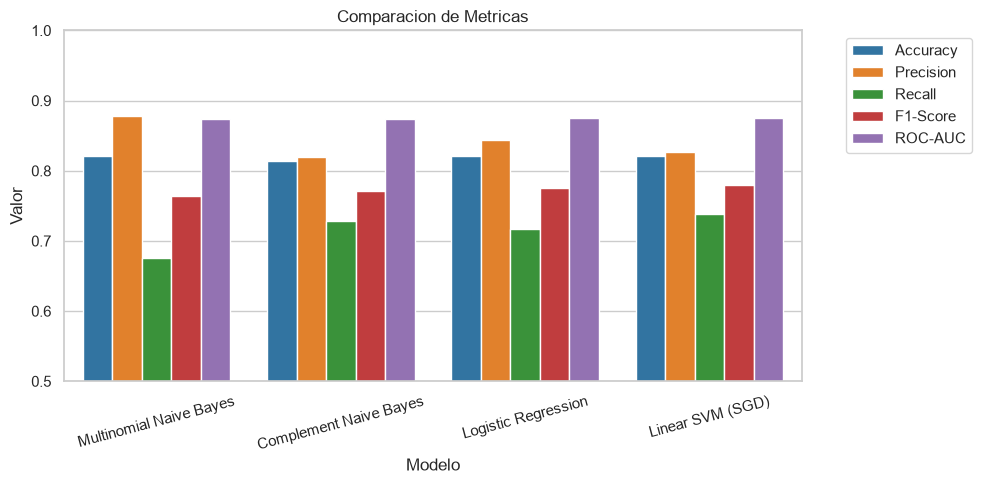

In [12]:
results_melted = pd.melt(results_df, id_vars=['Modelo'], var_name='Metrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(x='Modelo', y='Valor', hue='Metrica', data=results_melted, palette='tab10')
plt.title('Comparacion de Metricas')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

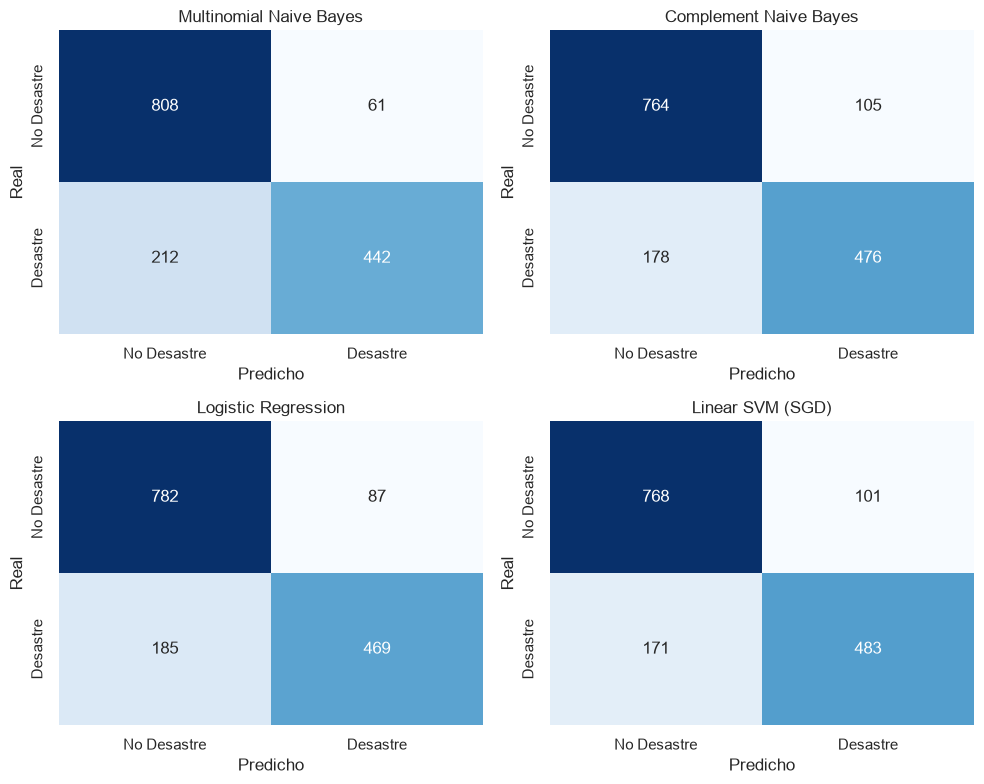

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for idx, (name, (model, y_pred, y_proba)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Desastre', 'Desastre'], yticklabels=['No Desastre', 'Desastre'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')
plt.tight_layout()
plt.show()

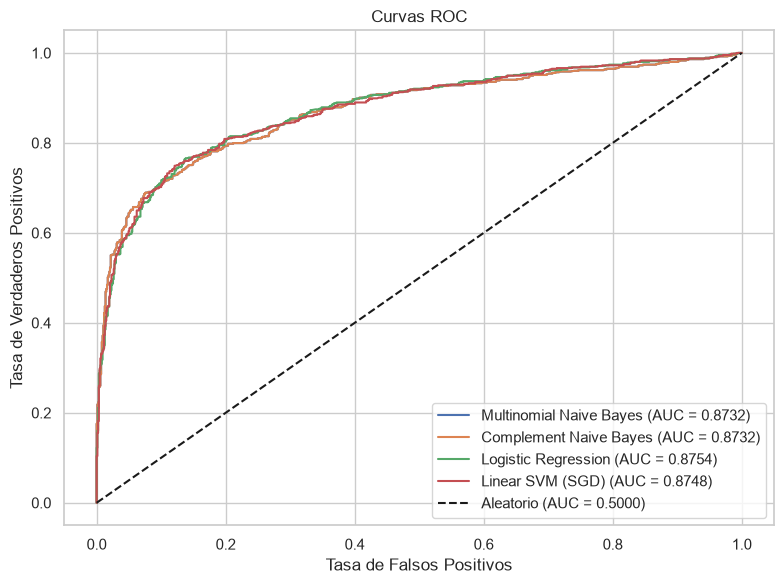

In [14]:
plt.figure(figsize=(8, 6))
for name, (model, y_pred, y_proba) in trained_models.items():
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_val, y_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5000)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Funcion de clasificacion (ejercicio 7)

Modelo final: Regresion Logistica, reentrenada sobre el 100% de `train.csv`.

In [15]:
def classify_tweet(text, model=None, vectorizer=None):
    """Clasifica un tweet crudo como desastre real (1) o no (0)."""
    if model is None or vectorizer is None:
        model = joblib.load('../models/best_model_logreg.joblib')
        vectorizer = joblib.load('../models/tfidf_vectorizer.joblib')

    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = int(model.predict(vec)[0])
    return {
        'text': text,
        'cleaned_text': cleaned,
        'label': pred,
        'label_desc': 'Desastre real' if pred == 1 else 'No es un desastre',
        'probability': float(model.predict_proba(vec)[0, 1])
    }

In [16]:
os.makedirs('../models', exist_ok=True)

tfidf_final = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_full_vec = tfidf_final.fit_transform(train_df['cleaned_text'])
best_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
best_model.fit(X_full_vec, train_df['target'])

joblib.dump(best_model, '../models/best_model_logreg.joblib')
joblib.dump(tfidf_final, '../models/tfidf_vectorizer.joblib')
print('Modelo y vectorizador guardados en models/.')

Modelo y vectorizador guardados en models/.


In [17]:
ejemplos = [
    'Forest fire near La Ronge Sask. Canada',
    "This new album is fire, I can't stop listening to it!",
    'BREAKING: Massive earthquake hits downtown, buildings collapsing #emergency',
    "I'm drowning in homework this week lol",
    "Call 911 immediately, there's been an explosion at the factory",
    'Just had the best burger of my life at this new restaurant downtown',
]

for tweet in ejemplos:
    r = classify_tweet(tweet, model=best_model, vectorizer=tfidf_final)
    print(f"{r['label_desc']:<20} (prob. = {r['probability']:.4f})  |  {r['text']}")

Desastre real        (prob. = 0.9186)  |  Forest fire near La Ronge Sask. Canada
No es un desastre    (prob. = 0.2667)  |  This new album is fire, I can't stop listening to it!
Desastre real        (prob. = 0.8762)  |  BREAKING: Massive earthquake hits downtown, buildings collapsing #emergency
No es un desastre    (prob. = 0.1351)  |  I'm drowning in homework this week lol
Desastre real        (prob. = 0.6547)  |  Call 911 immediately, there's been an explosion at the factory
No es un desastre    (prob. = 0.2055)  |  Just had the best burger of my life at this new restaurant downtown


In [18]:
tweet_usuario = "There's a huge fire spreading through the building downtown, send help!"
r = classify_tweet(tweet_usuario, model=best_model, vectorizer=tfidf_final)
print(f"Tweet: {r['text']}")
print(f"Preprocesado: {r['cleaned_text']}")
print(f"Clasificacion: {r['label_desc']} (probabilidad de desastre: {r['probability']:.2%})")

Tweet: There's a huge fire spreading through the building downtown, send help!
Preprocesado: huge fire spreading building downtown send help
Clasificacion: Desastre real (probabilidad de desastre: 80.08%)


## 7. Analisis de sentimiento (ejercicio 8)

Se cuentan las palabras positivas y negativas de cada tweet con el lexico de opinion de Hu y Liu,
y se calculan los puntajes de VADER sobre el texto crudo, que si conserva los emoticones.

In [19]:
for res in ['vader_lexicon', 'opinion_lexicon']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
pos_lex = set(opinion_lexicon.positive())
neg_lex = set(opinion_lexicon.negative())


def count_sentiment_words(text):
    tokens = str(text).split()
    return sum(t in pos_lex for t in tokens), sum(t in neg_lex for t in tokens)


def label_from_counts(n_pos, n_neg):
    if n_pos > n_neg:
        return 'positivo'
    if n_neg > n_pos:
        return 'negativo'
    return 'neutro'


def score_sentiment(raw_text, cleaned_text):
    n_pos, n_neg = count_sentiment_words(cleaned_text)
    total = n_pos + n_neg
    vs = sia.polarity_scores(str(raw_text))
    return {'n_pos': n_pos, 'n_neg': n_neg,
            'lex_score': (n_pos - n_neg) / total if total else 0.0,
            'sentiment_lex': label_from_counts(n_pos, n_neg),
            'vader_neg': vs['neg'], 'vader_neu': vs['neu'], 'vader_pos': vs['pos'],
            'vader_compound': vs['compound'], 'negatividad': vs['neg']}


scores = [score_sentiment(r, c) for r, c in zip(train_df['text'], train_df['cleaned_text'])]
train_df = pd.concat([train_df.reset_index(drop=True), pd.DataFrame(scores)], axis=1)

train_df['sentimiento'] = pd.cut(train_df['vader_compound'],
                                 bins=[-1.001, -0.05, 0.05, 1.0],
                                 labels=['negativo', 'neutro', 'positivo']).astype(str)

print('Por conteo de palabras del lexico:')
print(train_df['sentiment_lex'].value_counts())
print('\nPor VADER:')
print(train_df['sentimiento'].value_counts())

Por conteo de palabras del lexico:
sentiment_lex
negativo    3819
neutro      2819
positivo     975
Name: count, dtype: int64

Por VADER:
sentimiento
negativo    3707
neutro      2013
positivo    1893
Name: count, dtype: int64


In [20]:
# El ':/' de las URLs no es un emoticon: se exige limite de palabra a ambos lados.
EMOTICON_RE = re.compile(
    r"""(?:(?<=\s)|^)[:;=][\-o\*']?[\)\(\[\]DpP/\\\|\{\}@3]+(?=\s|$|[.,!?"'])"""
    r"""|(?:(?<=\s)|^)[xX]D(?=\s|$)"""
    r"""|<3"""
    r"""|[\U0001F300-\U0001FAFF\u2600-\u27BF]"""
)

tiene_emoticon = train_df['text'].astype(str).str.contains(EMOTICON_RE)
compound_sin = (train_df['text'].astype(str)
                .apply(lambda t: sia.polarity_scores(EMOTICON_RE.sub(' ', t))['compound']))
diff = (train_df['vader_compound'] - compound_sin).abs()
cambia = diff > 1e-9

emoticon_stats = pd.DataFrame([{
    'tweets_con_emoticon': int(tiene_emoticon.sum()),
    'porcentaje_con_emoticon': round(tiene_emoticon.mean() * 100, 2),
    'tweets_con_puntaje_alterado': int(cambia.sum()),
    'diferencia_media_abs_compound': round(diff.mean(), 4),
    'diferencia_media_abs_en_afectados': round(diff[cambia].mean(), 4)
}])
emoticon_stats

,tweets_con_emoticon,porcentaje_con_emoticon,tweets_con_puntaje_alterado,diferencia_media_abs_compound,diferencia_media_abs_en_afectados
0,69,0.91,64,0.003,0.3625


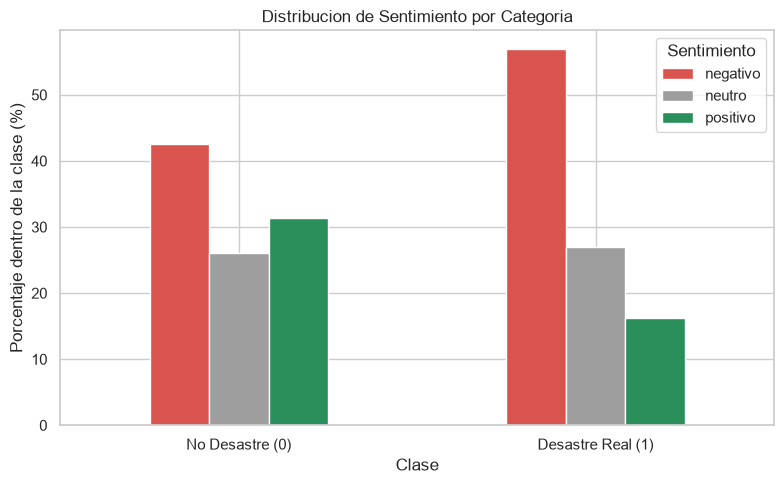

sentimiento,negativo,neutro,positivo
target,,,
0,42.51,26.09,31.39
1,56.89,26.90,16.20


In [21]:
ct = pd.crosstab(train_df['target'], train_df['sentimiento'], normalize='index') * 100
ct = ct.reindex(columns=['negativo', 'neutro', 'positivo'])

plt.figure(figsize=(8, 5))
ct.plot(kind='bar', color=['#d9534f', '#9e9e9e', '#2b8f5c'], ax=plt.gca())
plt.title('Distribucion de Sentimiento por Categoria')
plt.xlabel('Clase')
plt.ylabel('Porcentaje dentro de la clase (%)')
plt.xticks([0, 1], ['No Desastre (0)', 'Desastre Real (1)'], rotation=0)
plt.legend(title='Sentimiento')
plt.tight_layout()
plt.show()

ct.round(2)

## 8. Tweets mas negativos y mas positivos (ejercicio 9)

In [22]:
cols = ['text', 'target', 'vader_compound', 'n_pos', 'n_neg']
top_neg = train_df.nsmallest(10, 'vader_compound')[cols].copy()
top_neg['categoria'] = top_neg['target'].map({0: 'No desastre', 1: 'Desastre real'})
top_neg[['text', 'categoria', 'vader_compound']]

,text,categoria,vader_compound
7472,wreck? wreck wreck wreck wreck wreck wreck wre...,No desastre,-0.9883
6414,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...,Desastre real,-0.9686
6411,Suicide bomber kills 15 in Saudi security site...,Desastre real,-0.9623
6393,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,Desastre real,-0.9595
6407,17 killed in SÛªArabia mosque suicide bombing...,Desastre real,-0.9552
2932,at the lake \r\n*sees a dead fish*\r\nme: poor...,No desastre,-0.9549
472,illegal alien released by Obama/DHS 4 times Ch...,Desastre real,-0.9538
1540,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...,Desastre real,-0.9524
6818,Bomb head? Explosive decisions dat produced mo...,Desastre real,-0.9500
6930,@cspan #Prez. Mr. President you are the bigges...,Desastre real,-0.9493


In [23]:
top_pos = train_df.nlargest(10, 'vader_compound')[cols].copy()
top_pos['categoria'] = top_pos['target'].map({0: 'No desastre', 1: 'Desastre real'})
top_pos[['text', 'categoria', 'vader_compound']]

,text,categoria,vader_compound
6992,Check out 'Want Twister Tickets AND A VIP EXPE...,No desastre,0.9730
6534,@thoutaylorbrown I feel like accidents are jus...,No desastre,0.9564
6292,TodayÛªs storm will pass; let tomorrowÛªs li...,Desastre real,0.9471
3163,@batfanuk we enjoyed the show today. Great fun...,No desastre,0.9423
3382,@batfanuk we enjoyed the show today. Great fun...,No desastre,0.9423
6778,Maaaaan I love Love Without Tragedy by @rihann...,No desastre,0.9394
6295,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...,No desastre,0.9376
2457,@Raishimi33 :) well I think that sounds like a...,Desastre real,0.9356
1001,I'm not a Drake fan but I enjoy seeing him bod...,No desastre,0.9345
6560,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,No desastre,0.9344


In [24]:
neg_des = train_df.loc[train_df['target'] == 1, 'negatividad']
neg_no = train_df.loc[train_df['target'] == 0, 'negatividad']
u_stat, p_val = mannwhitneyu(neg_des, neg_no, alternative='greater')

print(f'Negatividad media, desastre real: {neg_des.mean():.4f}  (mediana {neg_des.median():.3f})')
print(f'Negatividad media, no desastre:   {neg_no.mean():.4f}  (mediana {neg_no.median():.3f})')
print(f'Mann-Whitney (desastre > no desastre): U = {u_stat:.1f}, p = {p_val:.3e}')

Negatividad media, desastre real: 0.1736  (mediana 0.157)
Negatividad media, no desastre:   0.1323  (mediana 0.088)
Mann-Whitney (desastre > no desastre): U = 8141444.5, p = 2.004e-30


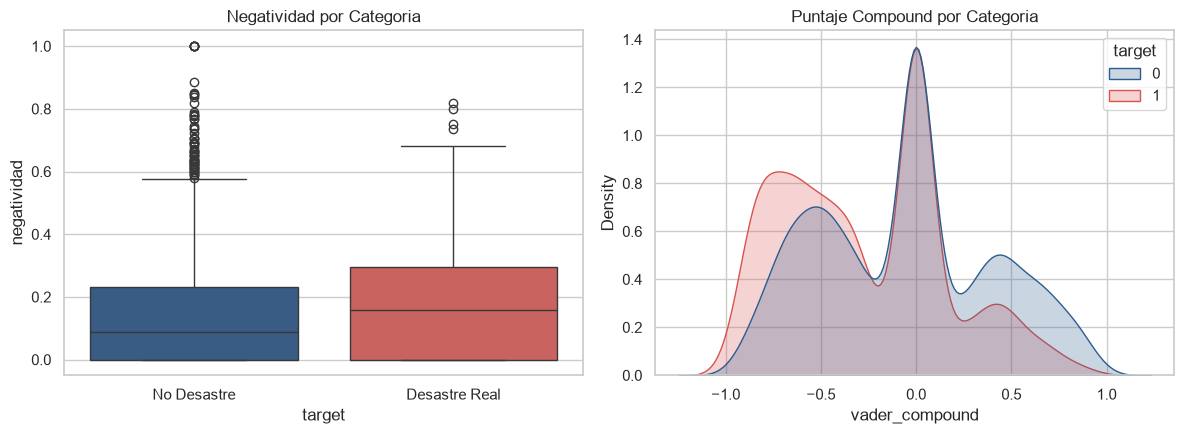

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=train_df, x='target', y='negatividad', ax=axes[0],
            palette=['#2b5c8f', '#d9534f'], hue='target', legend=False)
axes[0].set_title('Negatividad por Categoria')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Desastre', 'Desastre Real'])
sns.kdeplot(data=train_df, x='vader_compound', hue='target', fill=True, ax=axes[1],
            palette=['#2b5c8f', '#d9534f'], common_norm=False)
axes[1].set_title('Puntaje Compound por Categoria')
plt.tight_layout()
plt.show()

## 9. Variable de negatividad y reentrenamiento (ejercicio 10)

In [26]:
neg = train_df[['negatividad']].values
X_train, X_val, y_train, y_val, neg_train, neg_val = train_test_split(
    train_df['cleaned_text'], train_df['target'], neg,
    test_size=0.2, random_state=42, stratify=train_df['target'])

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)

X_train_neg = hstack([X_train_vec, csr_matrix(neg_train)]).tocsr()
X_val_neg = hstack([X_val_vec, csr_matrix(neg_val)]).tocsr()


def build_models():
    return {
        'Multinomial Naive Bayes': MultinomialNB(alpha=1.0),
        'Complement Naive Bayes': ComplementNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        'Linear SVM (SGD)': SGDClassifier(loss='log_loss', penalty='l2', random_state=42)
    }


filas = []
for etiqueta, Xtr, Xva in [('Sin negatividad', X_train_vec, X_val_vec),
                           ('Con negatividad', X_train_neg, X_val_neg)]:
    for nombre, modelo in build_models().items():
        modelo.fit(Xtr, y_train)
        y_pred = modelo.predict(Xva)
        p, r, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='binary')
        filas.append({'Conjunto': etiqueta, 'Modelo': nombre,
                      'Accuracy': accuracy_score(y_val, y_pred), 'Precision': p, 'Recall': r,
                      'F1-Score': f1,
                      'ROC-AUC': roc_auc_score(y_val, modelo.predict_proba(Xva)[:, 1])})

comp = pd.DataFrame(filas)
comp

,Conjunto,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Sin negatividad,Multinomial Naive Bayes,0.820749,0.878728,0.675841,0.764045,0.873168
1,Sin negatividad,Complement Naive Bayes,0.814183,0.819277,0.727829,0.770850,0.873168
2,Sin negatividad,Logistic Regression,0.821405,0.843525,0.717125,0.775207,0.875429
3,Sin negatividad,Linear SVM (SGD),0.821405,0.827055,0.738532,0.780291,0.874762
4,Con negatividad,Multinomial Naive Bayes,0.820749,0.880240,0.674312,0.763636,0.873283
5,Con negatividad,Complement Naive Bayes,0.815496,0.819897,0.730887,0.772838,0.873283
6,Con negatividad,Logistic Regression,0.816809,0.836625,0.712538,0.769612,0.874159
7,Con negatividad,Linear SVM (SGD),0.818779,0.832746,0.723242,0.774141,0.874172


In [27]:
pivote = comp.pivot(index='Modelo', columns='Conjunto', values=['Accuracy', 'F1-Score', 'ROC-AUC'])
delta = pd.DataFrame({
    'Modelo': pivote.index,
    'Delta_Accuracy': pivote['Accuracy']['Con negatividad'] - pivote['Accuracy']['Sin negatividad'],
    'Delta_F1': pivote['F1-Score']['Con negatividad'] - pivote['F1-Score']['Sin negatividad'],
    'Delta_ROC_AUC': pivote['ROC-AUC']['Con negatividad'] - pivote['ROC-AUC']['Sin negatividad']
}).reset_index(drop=True)
delta

,Modelo,Delta_Accuracy,Delta_F1,Delta_ROC_AUC
0,Complement Naive Bayes,0.001313,0.001987,0.000115
1,Linear SVM (SGD),-0.002626,-0.006150,-0.000590
2,Logistic Regression,-0.004596,-0.005595,-0.001270
3,Multinomial Naive Bayes,0.000000,-0.000409,0.000115


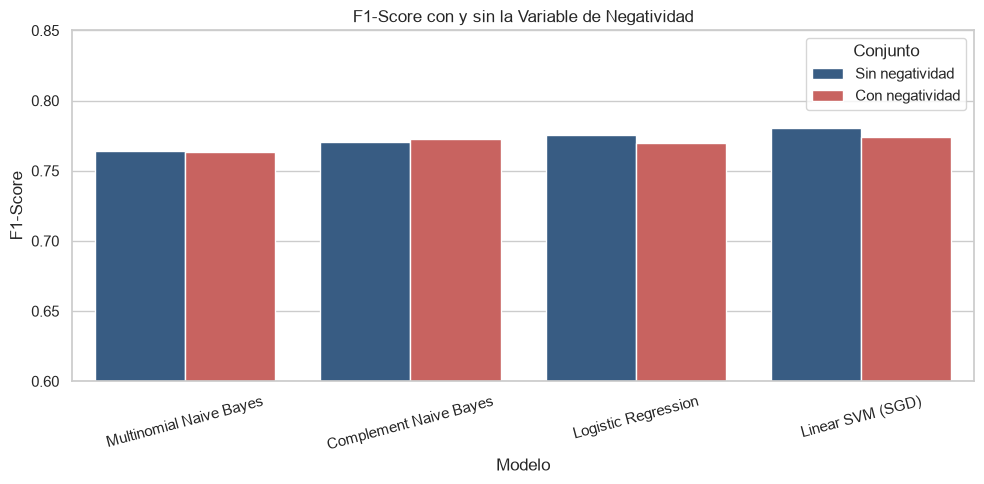

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comp, x='Modelo', y='F1-Score', hue='Conjunto', palette=['#2b5c8f', '#d9534f'])
plt.title('F1-Score con y sin la Variable de Negatividad')
plt.ylim(0.6, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [29]:
sens = [{'peso': 0.0, 'F1-Score': None,
         'ROC-AUC': roc_auc_score(y_val, neg_val.ravel()),
         'nota': 'negatividad como unico predictor'}]
for w in [1, 5, 10, 25]:
    Xtr_w = hstack([X_train_vec, csr_matrix(neg_train * w)]).tocsr()
    Xva_w = hstack([X_val_vec, csr_matrix(neg_val * w)]).tocsr()
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(Xtr_w, y_train)
    _, _, f1, _ = precision_recall_fscore_support(y_val, m.predict(Xva_w), average='binary')
    sens.append({'peso': w, 'F1-Score': f1,
                 'ROC-AUC': roc_auc_score(y_val, m.predict_proba(Xva_w)[:, 1]),
                 'nota': 'TF-IDF + negatividad escalada (Regresion Logistica)'})

pd.DataFrame(sens)

,peso,F1-Score,ROC-AUC,nota
0,0.0,NaN,0.572638,negatividad como unico predictor
1,1.0,0.769612,0.874159,TF-IDF + negatividad escalada (Regresion Logis...
2,5.0,0.766942,0.873992,TF-IDF + negatividad escalada (Regresion Logis...
3,10.0,0.769231,0.873948,TF-IDF + negatividad escalada (Regresion Logis...
4,25.0,0.766942,0.873987,TF-IDF + negatividad escalada (Regresion Logis...
